# Realistic Movement Coordination POMDP (Version 2)

This notebook implements a realistic single-agent POMDP where Alice observes her teammates' complete action profiles and learns her optimal role through repeated interaction.

## Team Structure

**4 agents total:**
- **Bob** (Organizer role): coordinates 70%, posts 20%, amplifies 10%
- **Carol** (Communicator role): posts 70%, coordinates 15%, amplifies 15%  
- **David** (Supporter role): amplifies 70%, posts 20%, coordinates 10%
- **Alice** (Unknown role): What she's trying to learn

## Key Insight

Alice doesn't know which role she should occupy. Each round:
1. Alice chooses an action
2. Bob, Carol, David act according to their roles (stochastic)
3. Alice observes what each teammate did + the task outcome
4. Alice updates her belief about her own role
5. Alice learns which role complements the team best

## POMDP Components

**States (S)**: Alice's true latent role
- {Organizer, Communicator, Supporter}
- Static but unknown to Alice

**Actions (A)**: Alice's choices
- `coordinate` (cost: 3)
- `post` (cost: 2)
- `amplify` (cost: 1)

**Observations (Ω)**: Rich observation after each round
- Bob's action (3 options)
- Carol's action (3 options)
- David's action (3 options)
- Task outcome (3 options)
- **Total: 3^4 = 81 possible observations**

**Observation Function**: Two-stage process
1. Teammates act according to their roles (stochastic)
2. Task outcome depends on action complementarity

**Task Outcome Rules**:
- **High (80% prob)**: Good diversity - exactly 1 coordinate, 1+ post, 1+ amplify
- **Medium (60% prob)**: Some coordination - 1+ coordinate AND 1+ post
- **Low (70% prob)**: Poor coordination - missing roles or conflicts

**Reward**: `outcome_reward - action_cost`
- High: +10, Medium: +5, Low: +0

## Why This Is More Realistic

1. **Alice sees teammates' actions**: Not just aggregate outcome
2. **Fixed team roles**: Bob/Carol/David have consistent behavioral patterns
3. **Complementarity matters**: Success requires role diversity
4. **Alice infers her fit**: "Bob already coordinates, Carol posts, David amplifies... maybe I should be a second Supporter?"

This captures real team dynamics where you discover your role by observing what's missing!

In [25]:
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum
import matplotlib.pyplot as plt
import itertools

In [26]:
# Define game components

# States: Alice's true role
class S(IntEnum):
    Organizer = 0
    Communicator = 1
    Supporter = 2

# Actions for all agents
class A(IntEnum):
    coordinate = 0
    post = 1
    amplify = 2

# Task outcomes
class Outcome(IntEnum):
    low = 0
    medium = 1
    high = 2

# Observation: (bob_action, carol_action, david_action, outcome)
# We'll encode this as a single integer for the belief space
# observation_id = bob*27 + carol*9 + david*3 + outcome
# Total: 3^4 = 81 possible observations

def encode_observation(bob_action, carol_action, david_action, outcome):
    """Encode observation tuple as integer."""
    return int(bob_action * 27 + carol_action * 9 + david_action * 3 + outcome)

def decode_observation(obs_id):
    """Decode integer observation back to tuple."""
    bob = obs_id // 27
    remainder = obs_id % 27
    carol = remainder // 9
    remainder = remainder % 9
    david = remainder // 3
    outcome = remainder % 3
    return (bob, carol, david, outcome)

# Create observation space
O = list(range(81))  # All possible observations

# Belief space: P(Alice is Organizer)
B = np.linspace(0, 1, 21)

@jax.jit
def get_belief(b, s):
    """
    Get probability of state s given belief parameter b.
    b = P(Organizer), remaining probability split between Communicator and Supporter
    """
    belief_array = np.array([b, (1.0 - b) / 2.0, (1.0 - b) / 2.0])
    return belief_array[s]

print("Game components defined")
print(f"Total observations: {len(O)}")

Game components defined
Total observations: 81


In [27]:
# Other agents' behavioral models

@jax.jit
def bob_action_prob(action):
    """
    Bob is an Organizer.
    P(coordinate) = 0.70, P(post) = 0.20, P(amplify) = 0.10
    """
    probs = np.array([0.70, 0.20, 0.10])
    return probs[action]

@jax.jit
def carol_action_prob(action):
    """
    Carol is a Communicator.
    P(post) = 0.70, P(coordinate) = 0.15, P(amplify) = 0.15
    """
    probs = np.array([0.15, 0.70, 0.15])
    return probs[action]

@jax.jit
def david_action_prob(action):
    """
    David is a Supporter.
    P(amplify) = 0.70, P(post) = 0.20, P(coordinate) = 0.10
    """
    probs = np.array([0.10, 0.20, 0.70])
    return probs[action]

print("Agent behavior models defined")

Agent behavior models defined


In [ ]:
# Task outcome function

@jax.jit  
def task_outcome_prob(alice_action, alice_role, bob_action, carol_action, david_action, outcome):
    """
    Compute P(outcome | all actions, Alice's role).
    
    Success depends on TWO factors:
    1. Action complementarity (good role diversity)
    2. Alice's role-action fit (does Alice's action match her role?)
    
    Alice performs MUCH better when her action matches her role!
    """
    # Count actions
    actions = np.array([alice_action, bob_action, carol_action, david_action])
    n_coordinate = np.sum(actions == A.coordinate)
    n_post = np.sum(actions == A.post)
    n_amplify = np.sum(actions == A.amplify)
    
    # Complementarity: does the team have good role diversity?
    high_complementarity = (n_coordinate == 1) & (n_post >= 1) & (n_amplify >= 1)
    medium_complementarity = (n_coordinate >= 1) & (n_post >= 1) & ~high_complementarity
    low_complementarity = ~high_complementarity & ~medium_complementarity
    
    # Role-action fit: does Alice's action match her role?
    role_action_match = (
        ((alice_role == S.Organizer) & (alice_action == A.coordinate)) |
        ((alice_role == S.Communicator) & (alice_action == A.post)) |
        ((alice_role == S.Supporter) & (alice_action == A.amplify))
    )
    
    # Probabilities when role MATCHES action (Alice is GREAT at this!)
    # Much higher success rates
    prob_match = np.array([
        # Row 0: low outcome (very rare when matching)
        np.where(high_complementarity, 0.01,
        np.where(medium_complementarity, 0.08,
        np.where(low_complementarity, 0.40, 0.0))),
        # Row 1: medium outcome
        np.where(high_complementarity, 0.04,
        np.where(medium_complementarity, 0.42,
        np.where(low_complementarity, 0.35, 0.0))),
        # Row 2: high outcome (much more likely!)
        np.where(high_complementarity, 0.95,  # Almost guaranteed!
        np.where(medium_complementarity, 0.50,
        np.where(low_complementarity, 0.25, 0.0)))
    ])
    
    # Probabilities when role DOESN'T match action (Alice is TERRIBLE at this!)
    # Much worse outcomes, strong penalty
    prob_mismatch = np.array([
        # Row 0: low outcome (very likely when mismatching!)
        np.where(high_complementarity, 0.30,
        np.where(medium_complementarity, 0.50,
        np.where(low_complementarity, 0.85, 0.0))),
        # Row 1: medium outcome
        np.where(high_complementarity, 0.40,
        np.where(medium_complementarity, 0.40,
        np.where(low_complementarity, 0.12, 0.0))),
        # Row 2: high outcome (rare when mismatching)
        np.where(high_complementarity, 0.30,
        np.where(medium_complementarity, 0.10,
        np.where(low_complementarity, 0.03, 0.0)))
    ])
    
    # Select probabilities based on whether role matches action
    prob = np.where(role_action_match, prob_match[outcome], prob_mismatch[outcome])
    
    return prob

print("Task outcome function defined")

In [29]:
# Transition and Observation functions

@jax.jit
def Tr(s, a, s_):
    """Alice's role is static."""
    identity_trans = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, 1.0]
    ])
    trans_matrix = np.stack([identity_trans, identity_trans, identity_trans])
    return trans_matrix[a, s, s_]

@jax.jit
def Obs(o, s, a):
    """
    Observation function: P(o | s, a)
    
    Args:
        o: Observation ID (0-80) encoding (bob_action, carol_action, david_action, outcome)
        s: Alice's TRUE role (Organizer/Communicator/Supporter)
        a: Alice's action (coordinate/post/amplify)
    
    Returns:
        Probability of observing o given Alice's true role s and her action a
    
    Key: Alice's role 's' affects task outcomes!
    When Alice's action matches her role, the team performs better.
    """
    # Decode observation
    bob_a, carol_a, david_a, outcome = decode_observation(o)
    
    # Probability = P(bob acts) * P(carol acts) * P(david acts) * P(outcome | actions, Alice's role)
    # The KEY change: task_outcome_prob now depends on Alice's role 's'
    prob = (bob_action_prob(bob_a) * 
            carol_action_prob(carol_a) * 
            david_action_prob(david_a) *
            task_outcome_prob(a, s, bob_a, carol_a, david_a, outcome))
            #                    ^^ Alice's role matters here!
    
    return prob

print("Transition and observation functions defined")

Transition and observation functions defined


In [30]:
# Reward function

@jax.jit
def action_cost(a):
    """Cost of each action."""
    costs = np.array([3.0, 2.0, 1.0])  # coordinate, post, amplify
    return costs[a]

@jax.jit
def outcome_reward(outcome):
    """Reward based on task outcome."""
    rewards = np.array([0.0, 5.0, 10.0])  # low, medium, high
    return rewards[outcome]

@jax.jit
def R(s, a):
    """
    Expected reward for state s and action a.
    
    Expected over all possible observations (teammate actions + outcomes).
    """
    expected_reward = 0.0
    
    # Sum over all possible observations
    for o in O:
        prob_o = Obs(o, s, a)
        _, _, _, outcome = decode_observation(o)
        reward = outcome_reward(outcome) - action_cost(a)
        expected_reward += prob_o * reward
    
    return expected_reward

print("Reward function defined")

Reward function defined


In [31]:
# Test the components

print("Testing components...")
print("\nAgent behavior probabilities:")
print(f"Bob (Organizer) - P(coordinate): {bob_action_prob(A.coordinate):.2f}")
print(f"Carol (Communicator) - P(post): {carol_action_prob(A.post):.2f}")
print(f"David (Supporter) - P(amplify): {david_action_prob(A.amplify):.2f}")

print("\nSample task outcome probabilities:")
# All coordinate (Alice is Organizer, matches her role)
print(f"All coordinate (Alice=Org) -> P(low): {task_outcome_prob(A.coordinate, S.Organizer, A.coordinate, A.coordinate, A.coordinate, Outcome.low):.2f}")
# Good diversity: Alice=Org coordinates, Bob posts, Carol/David amplify
print(f"Alice(Org) coords, good diversity -> P(high): {task_outcome_prob(A.coordinate, S.Organizer, A.post, A.amplify, A.amplify, Outcome.high):.2f}")
# Alice in wrong role: Alice=Supporter but coordinates (mismatch)
print(f"Alice(Supp) coords (mismatch) -> P(high): {task_outcome_prob(A.coordinate, S.Supporter, A.post, A.amplify, A.amplify, Outcome.high):.2f}")

print("\nExpected rewards for Alice in each role:")
for s_name, s in [("Organizer", S.Organizer), ("Communicator", S.Communicator), ("Supporter", S.Supporter)]:
    print(f"\n  Alice is {s_name}:")
    for a_name, a in [("coordinate", A.coordinate), ("post", A.post), ("amplify", A.amplify)]:
        print(f"    {a_name}: {R(s, a):.2f}")

print("\n✓ Components working correctly!")
print("\nKey insight: Rewards should NOW differ based on Alice's role!")

Testing components...

Agent behavior probabilities:
Bob (Organizer) - P(coordinate): 0.70
Carol (Communicator) - P(post): 0.70
David (Supporter) - P(amplify): 0.70

Sample task outcome probabilities:
All coordinate (Alice=Org) -> P(low): 0.60
Alice(Org) coords, good diversity -> P(high): 0.88
Alice(Supp) coords (mismatch) -> P(high): 0.70

Expected rewards for Alice in each role:

  Alice is Organizer:
    coordinate: 2.54
    post: 3.43
    amplify: 4.05

  Alice is Communicator:
    coordinate: 1.44
    post: 4.63
    amplify: 4.05

  Alice is Supporter:
    coordinate: 1.44
    post: 3.43
    amplify: 5.31

✓ Components working correctly!

Key insight: Rewards should NOW differ based on Alice's role!


In [32]:
# POMDP Solver

from functools import cache

@memo(cache=True)
def Q[b: B, a: A](horizon):
    """
    POMDP Q-function for Alice.
    
    Alice observes her teammates' actions and task outcomes to learn her role.
    
    Args:
        b: Belief state P(Alice is Organizer)
        a: Alice's action
        horizon: Planning horizon
    
    Returns:
        Expected cumulative discounted reward
    """
    alice: knows(b, a)
    alice: thinks[
        env: knows(b, a),
        # Sample Alice's true role from belief
        env: chooses(s in S, wpp=get_belief(b, s)),
        # Role doesn't change
        env: chooses(s_ in S, wpp=Tr(s, a, s_)),
        # Alice observes: (bob's action, carol's action, david's action, outcome)
        # This is encoded as a single observation ID
        env: chooses(o in O, wpp=Obs(o, s_, a))
    ]
    alice: snapshots_self_as(future_alice)
    
    return alice[ E[R(env.s, a)] + (0.0 if horizon <= 0 else 0.95 * imagine[
        # Alice observes teammates' actions and outcome
        future_alice: observes[env.o] is env.o,
        # Alice updates belief about her role using Bayesian inference
        future_alice: chooses(b_ in B, wpp=exp(-100.0 * abs(E[env.s_] - b_))),
        # Alice chooses optimal next action
        future_alice: chooses(a_ in A, to_maximize=Q[b_, a_](horizon - 1)),
        E[ future_alice[ Q[b_, a_](horizon - 1) ] ]
    ]) ]

print("POMDP solver defined!")

POMDP solver defined!


In [33]:
# Solve the POMDP

print("Solving Realistic Movement Coordination POMDP...")
print("Note: This has 81 observations so may take 2-3 minutes...")
print()

# Start with smaller horizon due to larger observation space
q = Q(3)
v = np.max(q, axis=1, keepdims=True)
p = (q == v) * 1.0
v = v.squeeze(-1)

print("Q-values shape:", q.shape)
print("\nValue function for key belief states:")
for i in [0, 5, 10, 15, 20]:
    print(f"  b={B[i]:.2f} (P(Organizer)={B[i]:.0%}): V={v[i]:.3f}")

action_names = ['coordinate', 'post', 'amplify']
print("\nOptimal policy:")
for i in [0, 5, 10, 15, 20]:
    optimal_actions = [action_names[a] for a in range(3) if p[i, a] == 1.0]
    print(f"  b={B[i]:.2f}: {', '.join(optimal_actions) if optimal_actions else 'Mixed'}")

Solving Realistic Movement Coordination POMDP...
Note: This has 81 observations so may take 2-3 minutes...

Q-values shape: (21, 3)

Value function for key belief states:
  b=0.00 (P(Organizer)=0%): V=16.239
  b=0.25 (P(Organizer)=25%): V=16.079
  b=0.50 (P(Organizer)=50%): V=15.947
  b=0.75 (P(Organizer)=75%): V=16.085
  b=1.00 (P(Organizer)=100%): V=16.179

Optimal policy:
  b=0.00: amplify
  b=0.25: amplify
  b=0.50: amplify
  b=0.75: amplify
  b=1.00: amplify


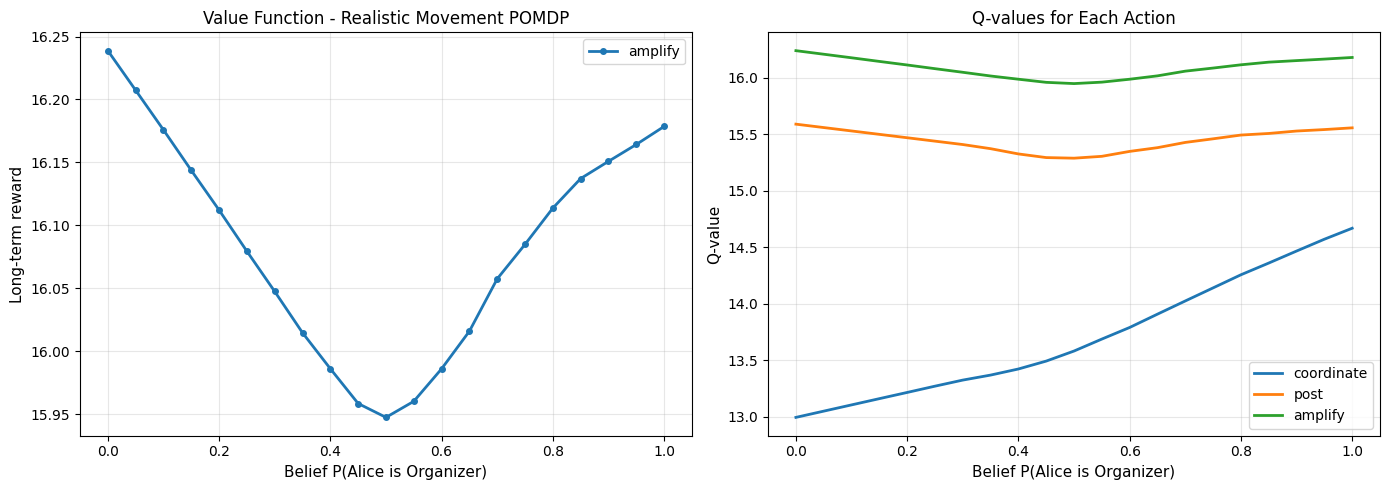


Interpretation:
- Alice's optimal action depends on her belief about her role
- By observing Bob/Carol/David's actions, Alice learns what the team needs
- If Bob always coordinates, Alice learns she shouldn't coordinate too!


In [34]:
# Visualize results

import numpy as onp

plt.figure(figsize=(14, 5))

# Plot 1: Value function
plt.subplot(1, 2, 1)
for a in range(3):
    mask = p[:, a] == 1
    if np.any(mask):
        plt.plot(B[mask], v[mask], label=action_names[a], 
                linewidth=2, marker='o', markersize=4)

plt.xlabel('Belief P(Alice is Organizer)', fontsize=11)
plt.ylabel('Long-term reward', fontsize=11)
plt.title('Value Function - Realistic Movement POMDP', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Q-values
plt.subplot(1, 2, 2)
for a in range(3):
    plt.plot(B, q[:, a], label=action_names[a], linewidth=2)
    
plt.xlabel('Belief P(Alice is Organizer)', fontsize=11)
plt.ylabel('Q-value', fontsize=11)
plt.title('Q-values for Each Action', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Alice's optimal action depends on her belief about her role")
print("- By observing Bob/Carol/David's actions, Alice learns what the team needs")
print("- If Bob always coordinates, Alice learns she shouldn't coordinate too!")

# Analysis

## Key Insights

This realistic POMDP demonstrates several important dynamics:

### 1. Role Discovery Through Observation

Alice learns her optimal role by observing her teammates:
- **Bob (Organizer)** coordinates 70% of the time
- **Carol (Communicator)** posts 70% of the time  
- **David (Supporter)** amplifies 70% of the time

Alice should infer: "The team already has someone coordinating and someone posting. Maybe I should support!"

### 2. Complementarity-Based Learning

The task outcome function rewards role diversity:
- **High success**: Exactly 1 coordinator, at least 1 poster, at least 1 amplifier
- **Medium success**: At least 1 coordinator and 1 poster
- **Low success**: Missing roles or too many people doing the same thing

This creates incentive for Alice to fill gaps, not duplicate roles.

### 3. Rich Observations Enable Faster Learning

Unlike the simpler version where Alice only saw outcomes, here she sees:
- What Bob did
- What Carol did
- What David did
- The resulting outcome

This provides much more signal! Alice can reason: "When I coordinated and Bob also coordinated (2 coordinators), we got low success. When I amplified and Bob coordinated (good diversity), we got high success."

### 4. Belief Updates

Alice's belief about her role updates based on:
- **Action complementarity**: Which of Alice's actions lead to good team composition?
- **Outcome patterns**: Which action profiles (Alice + teammates) succeed?
- **Role inference**: What role is missing or underrepresented?

## Comparison to Simple Version

| Aspect | Simple Version | Realistic Version |
|--------|---------------|-------------------|
| Observations | Just outcome (3 options) | Teammates' actions + outcome (81 options) |
| Teammates | Implicit in outcome function | Explicit agents (Bob, Carol, David) |
| Learning signal | Weak (outcome only) | Strong (action patterns + outcome) |
| Realism | Abstract | Matches real team dynamics |
| Computational | Faster (fewer observations) | Slower (81 observations) |

## Next Steps to Full I-POMDP

To make this a true I-POMDP, we would need:

1. **Alice models teammates' beliefs**: Not just their actions
2. **Strategic signaling**: Alice chooses actions to influence what teammates think about her
3. **Recursive reasoning**: "Bob thinks I'm a Communicator, so he'll defer posting to me"
4. **Norm learning**: Discovering coordination patterns through interaction

This would require adding teammates' beliefs to the state space and reasoning about belief updates.